In [1]:
from src.config import FEATURE_SENSORS as F
from src.features import prepare

p = prepare()
for name in ["fit_healthy", "val_healthy", "val", "test"]:
    d = getattr(p, name)
    print(
        f"{name:12s} rows={len(d):6d} units={d.unit.nunique():3d} "
        f"mean|z|={d[F].mean().abs().mean():.2f} std={d[F].std().mean():.2f}"
    )
print("overlap fit/val:", set(p.fit_healthy.unit) & set(p.val.unit))

fit_healthy  rows=  2400 units= 80 mean|z|=0.00 std=1.00
val_healthy  rows=   600 units= 20 mean|z|=0.03 std=1.00
val          rows=  3852 units= 20 mean|z|=0.90 std=1.62
test         rows= 13096 units=100 mean|z|=0.27 std=1.12
overlap fit/val: set()


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

p = prepare()
late = p.val[p.val["rul"] < 30]  # The last 30 cycles of the VAL motors: “corrupted” reference

In [3]:
eff = pd.DataFrame({"healthy": p.val_healthy[F].mean(), "late": late[F].mean()})
eff["shift"] = eff["late"] - eff["healthy"]
eff.round(2).sort_values("shift", key=abs, ascending=False)

,healthy,late,shift
Nc,-0.08,4.58,4.66
NRc,-0.04,3.58,3.62
Ps30,-0.03,3.37,3.40
T50,-0.04,3.35,3.39
phi,0.02,-3.09,-3.11
BPR,0.01,2.98,2.97
P30,0.02,-2.91,-2.93
W31,0.01,-2.86,-2.87
W32,-0.03,-2.82,-2.79
htBleed,-0.02,2.67,2.69


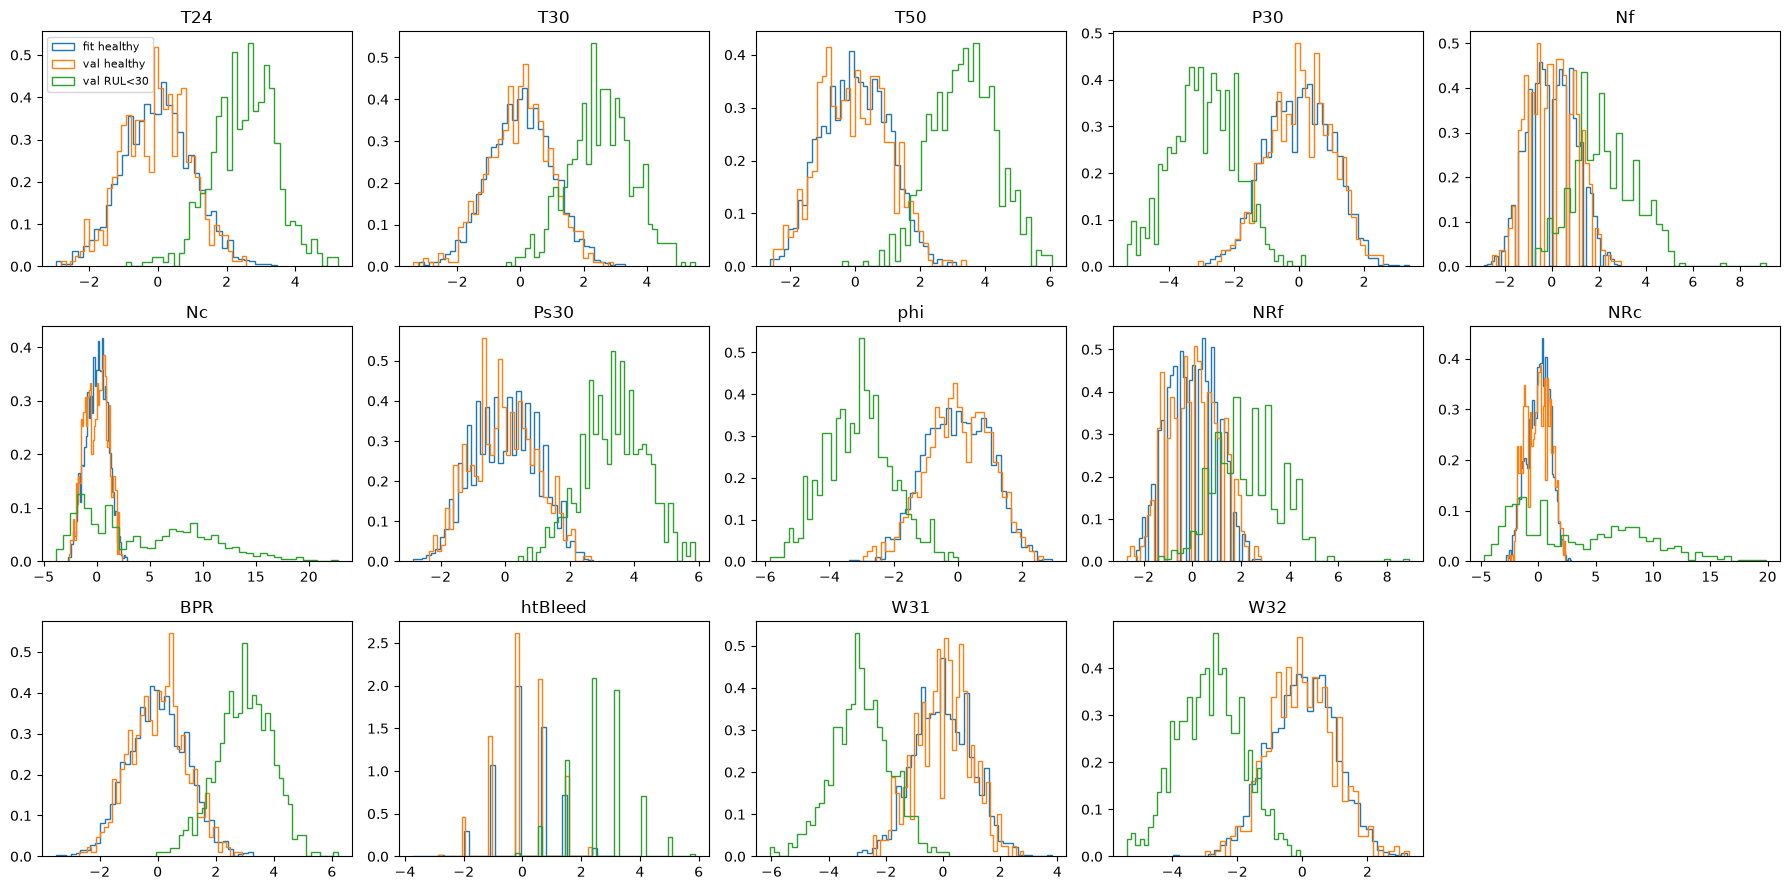

In [4]:
# How do the distributions differ?
fig, axes = plt.subplots(3, 5, figsize=(18, 9))

for ax, s in zip(axes.flat[: len(F)], F, strict=True):
    for name, d in [
        ("fit healthy", p.fit_healthy),
        ("val healthy", p.val_healthy),
        ("val RUL<30", late),
    ]:
        ax.hist(d[s], bins=40, density=True, histtype="step", label=name)
    ax.set_title(s)
axes.flat[-1].axis("off")
axes.flat[0].legend(fontsize=8)
plt.tight_layout()

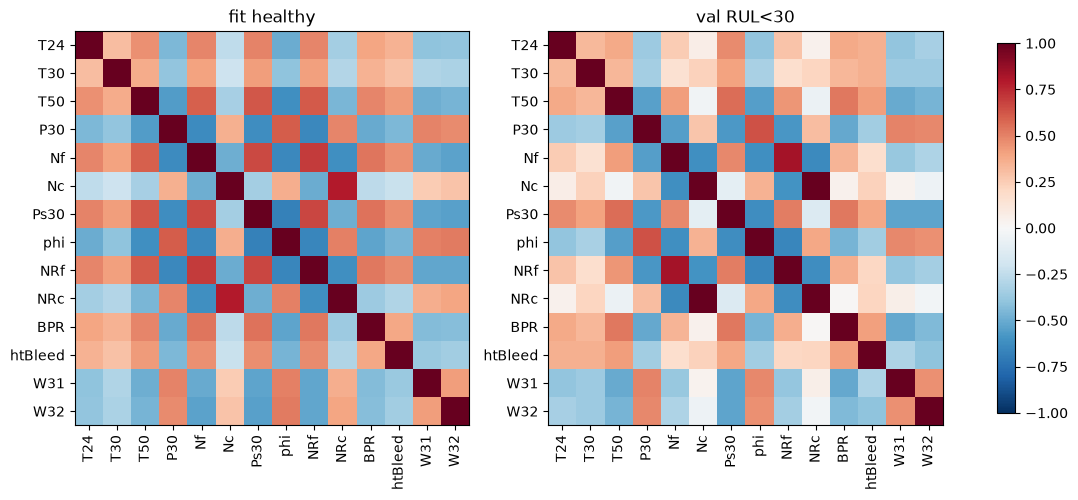

In [5]:
# How do the sensors work together?
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, d) in zip(axes, [("fit healthy", p.fit_healthy), ("val RUL<30", late)], strict=True):
    im = ax.imshow(d[F].corr(), cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(F)), F, rotation=90)
    ax.set_yticks(range(len(F)), F)
    ax.set_title(name)
fig.colorbar(im, ax=axes, shrink=0.8)

In [6]:
# How much of the difference in the valid data is due to variations between engines?
fh = p.fit_healthy
between = fh.groupby("unit")[F].mean().var()  # variance of the motor means
total = fh[F].var()
(between / total).round(2).sort_values(ascending=False)

NRc        0.86
Nc         0.76
NRf        0.72
Ps30       0.70
Nf         0.69
phi        0.65
P30        0.60
T50        0.57
BPR        0.46
W31        0.44
W32        0.42
T24        0.40
htBleed    0.37
T30        0.28
dtype: float64

In [7]:
# Is a “healthy window” really static?
def drift(g):
    return pd.Series({s: np.polyfit(g["cycle"], g[s], 1)[0] * 30 for s in F})


fh.groupby("unit")[["cycle"] + F].apply(drift).mean().round(2).sort_values()

W32       -0.11
phi       -0.10
W31       -0.05
P30       -0.01
NRc        0.02
BPR        0.03
Nc         0.04
htBleed    0.05
T30        0.06
NRf        0.06
T24        0.07
T50        0.07
Nf         0.07
Ps30       0.11
dtype: float64

In [8]:
# Are consecutive cycles connected to one another?
fh.groupby("unit")[F].apply(lambda g: g.apply(lambda s: s.autocorr(1))).mean().round(
    2
).sort_values()

P30       -0.06
BPR       -0.06
W31       -0.06
T50       -0.04
W32       -0.04
T24       -0.03
Nf        -0.02
T30       -0.02
htBleed   -0.02
NRf       -0.02
Ps30      -0.02
Nc        -0.01
NRc       -0.01
phi        0.00
dtype: float64

Lag-1 autocorrelation measures how closely the value in one cycle is related to the value in the next cycle. If it is close to 0, it means that consecutive measurements behave like independent noise.

In [9]:
for name, d in [("fit_healthy", p.fit_healthy), ("val full life", p.val)]:
    cum = np.cumsum(PCA().fit(d[F]).explained_variance_ratio_)
    print(f"{name:14s} cum var {np.round(cum[:6], 2)}  n for 95%: {np.searchsorted(cum, 0.95) + 1}")

fit_healthy    cum var [0.51 0.6  0.65 0.7  0.74 0.78]  n for 95%: 12
val full life  cum var [0.52 0.86 0.88 0.9  0.91 0.93]  n for 95%: 8


In the valid data, there is a single dominant component that most likely represents the difference between the engines. The rest is mostly independent noise, so nearly all dimensions are needed to explain the variance. The interpretation that “the first component represents the difference between the engines” is, for now, a hypothesis. It is consistent with the fourth analysis, but we have not tested it directly.

- fit_healthy    cum var [0.51 0.6  0.65 0.7  0.74 0.78]  n for 95%: 12
- val full life  cum var [0.52 0.86 0.88 0.9  0.91 0.93]  n for 95%: 8

## Findings → Conclusions
1. All sensors near the failure point show a healthy-std drift of 2.2–4.7 (val healthy vs. val RUL<30).
2. The RUL < 30 distribution in Nc/NRc is two-peaked (part of it downward, part of it upward up to +20):
   The average deviation of 4.66 does not represent individual motors.
3. Nf, NRf, and htBleed are discrete (resolution 0.01 rpm / integer) → comb-like structure in the histogram;
   may limit IF bins.
4. 28–86% of the healthy variance is inter-motor (initial wear) → motor-based normalization
   will be performed.
5. A single sensor block in healthy correlation (PC1 51%); the Nc/NRc block detaches as it nears failure,
   its relationship with Nf turns negative → the correlation structure changes (SPE is expected to capture this).
6. Drift ≤ 0.11 std in the first 30 cycles → supports the healthy window assumption.
7. Lag-1 autocorrelation ≈ 0 (white noise, consistent with −1/n bias) → time information is in a slow trend;
   LSTM-AE gain most likely comes from the mean of the noise → window PCA tests this.
8. Sound PCA: 12/14 components for 95% variance → the number of components will determine the SPE/T² balance.